In [27]:
# --- Main Configuration Cell ---

# 1. Data Generation Settings
DATA_CONFIG = {
    'output_dir': 'data',
    'num_aircraft': 5,
    'num_anomalous_aircraft': 1,
    'flight_duration_hours': 4,
    'points_per_hour': 60,
    'sensor_names': ['engine_rpm', 'fuel_flow', 'engine_temperature', 'vibration_level']
}

# 2. Model Architecture
MODEL_CONFIG = {
    'input_dim': len(DATA_CONFIG['sensor_names']),
    'hidden_dim': 32,
    'latent_dim': 8
}

# 3. Training Parameters
TRAINING_CONFIG = {
    'centralized_epochs': 50,
    'federated_rounds': 10,
    'federated_local_epochs': 5,
    'learning_rate': 0.001,
}

print("✅ Configuration loaded.")

✅ Configuration loaded.


In [28]:
import os
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler

from anomfl.data_generation.aircraft_data_generator import Fleet
from anomfl.autoencoders.autoencoder import Autoencoder
from anomfl.federated.centralized_server import FederatedClient, CentralizedServer

print("Libraries imported.")

Libraries imported.


In [29]:
# --- Fixed Scaling Import ---
from anomfl.utils import get_aircraft_scaler, scale_aircraft_data
print("✅ Fixed scaling utilities imported")


✅ Fixed scaling utilities imported


In [30]:
print("--- Starting Data Generation ---")

# Clean up old data directory
if os.path.exists(DATA_CONFIG['output_dir']):
    shutil.rmtree(DATA_CONFIG['output_dir'])

# Calculate parameters for the Fleet class
FLEET_ID = 1
num_points = DATA_CONFIG['flight_duration_hours'] * DATA_CONFIG['points_per_hour']
interval_minutes = 60 // DATA_CONFIG['points_per_hour']

# Create the Fleet object
fleet = Fleet(
    fleet_id=FLEET_ID,
    num_aircraft=DATA_CONFIG['num_aircraft'],
    num_anomalous=DATA_CONFIG['num_anomalous_aircraft'],
    num_points=num_points,
    interval_minutes=interval_minutes
)

# Generate and save the data
fleet.generate_fleet_data(output_dir=DATA_CONFIG['output_dir'])

# Store file paths for later use
anomalous_ids = {record['aircraft_id'] for record in fleet.anomaly_records}
file_paths = []
for aircraft in fleet.aircraft_list:
    suffix = "_anomalous.csv" if aircraft.id in anomalous_ids else "_normal.csv"
    path = os.path.join(DATA_CONFIG['output_dir'], f"fleet_{FLEET_ID}", f"aircraft_{FLEET_ID}_{aircraft.id}{suffix}")
    file_paths.append(path)

print(f"\n✅ Data generation complete.")

--- Starting Data Generation ---
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_1_anomalous.csv
Aircraft 1-1 generated (Anomalous)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_2_normal.csv
Aircraft 1-2 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_3_normal.csv
Aircraft 1-3 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_4_normal.csv
Aircraft 1-4 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_5_normal.csv
Aircraft 1-5 generated (Normal)
Anomaly summary saved as d:\DL\FL\AnomFL\examples\data\fleet_1\fleet_1_anomalies.csv

✅ Data generation complete.


In [31]:
print("\n--- Training Centralized Model ---")

# Load data from NORMAL aircraft only (exclude anomalous)
normal_paths = [p for p in file_paths if "anomalous" not in p]
print(f"Loading data from {len(normal_paths)} normal aircraft files:")
for i, path in enumerate(normal_paths):
    print(f"  Normal Aircraft {i+1}: {os.path.basename(path)}")

normal_dfs = [pd.read_csv(p) for p in normal_paths]
all_normal_data_df = pd.concat(normal_dfs, ignore_index=True)
sensor_data = all_normal_data_df[DATA_CONFIG['sensor_names']]

# Fit a single scaler on normal data only
scaler = get_aircraft_scaler(include_anomalies=False)  # Fixed scaling
scaled_data = scaler.transform(sensor_data)
train_tensor = torch.tensor(scaled_data, dtype=torch.float32)

# Instantiate and train the model on normal data only
centralized_model = Autoencoder(
    input_dim=MODEL_CONFIG['input_dim'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    latent_dim=MODEL_CONFIG['latent_dim']
)
centralized_model.train_on_tensor(
    train_tensor,
    num_epochs=TRAINING_CONFIG['centralized_epochs'],
    lr=TRAINING_CONFIG['learning_rate']
)

# Calculate and print final MSE statistic on normal data
centralized_model.eval()
with torch.no_grad():
    reconstructed = centralized_model(train_tensor)
    final_loss = nn.MSELoss()(reconstructed, train_tensor)
print(f"\n📊 Final MSE on Normal Training Data (Centralized): {final_loss.item():.8f}")



--- Training Centralized Model ---
Loading data from 4 normal aircraft files:
  Normal Aircraft 1: aircraft_1_2_normal.csv
  Normal Aircraft 2: aircraft_1_3_normal.csv
  Normal Aircraft 3: aircraft_1_4_normal.csv
  Normal Aircraft 4: aircraft_1_5_normal.csv
Starting training...
  Epoch [10/50], Loss: 0.001045
  Epoch [20/50], Loss: 0.000349
  Epoch [30/50], Loss: 0.000482
  Epoch [40/50], Loss: 0.000471
  Epoch [50/50], Loss: 0.000299

📊 Final MSE on Normal Training Data (Centralized): 0.00034295


In [32]:
print("\n--- Training Federated Model ---")

# Create a client for each aircraft
clients = [
    FederatedClient(client_id=i + 1, file_path=file_paths[i])
    for i in range(DATA_CONFIG['num_aircraft'])
]

# Create a base model instance for the server
base_model = Autoencoder(
    input_dim=MODEL_CONFIG['input_dim'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    latent_dim=MODEL_CONFIG['latent_dim']
)

# Instantiate the server
server = CentralizedServer(clients=clients, model=base_model)

# Run the federated training process
server.train(
    rounds=TRAINING_CONFIG['federated_rounds'],
    local_epochs=TRAINING_CONFIG['federated_local_epochs'],
    lr=TRAINING_CONFIG['learning_rate']
)
federated_model = server.global_model

# Calculate and print final MSE statistic
federated_model.eval()
with torch.no_grad():
    reconstructed = federated_model(train_tensor)
    final_loss = nn.MSELoss()(reconstructed, train_tensor)
print(f"\n📊 Final MSE on All Training Data (Federated): {final_loss.item():.8f}")


--- Training Federated Model ---

ROUND 1/10
  -> Training Client 1...
    Epoch [2/5], Client Loss: 0.041222
    Epoch [4/5], Client Loss: 0.034263
  -> Training Client 2...
    Epoch [2/5], Client Loss: 0.049256
    Epoch [4/5], Client Loss: 0.031316
  -> Training Client 3...
    Epoch [2/5], Client Loss: 0.037566
    Epoch [4/5], Client Loss: 0.044535
  -> Training Client 4...
    Epoch [2/5], Client Loss: 0.035419
    Epoch [4/5], Client Loss: 0.038031
  -> Training Client 5...
    Epoch [2/5], Client Loss: 0.031433
    Epoch [4/5], Client Loss: 0.023121

ROUND 2/10
  -> Training Client 1...
    Epoch [2/5], Client Loss: 0.042835
    Epoch [4/5], Client Loss: 0.041621
  -> Training Client 2...
    Epoch [2/5], Client Loss: 0.042658
    Epoch [4/5], Client Loss: 0.047564
  -> Training Client 3...
    Epoch [2/5], Client Loss: 0.028133
    Epoch [4/5], Client Loss: 0.032473
  -> Training Client 4...
    Epoch [2/5], Client Loss: 0.029720
    Epoch [4/5], Client Loss: 0.034794
  -> T


--- Generating Comparison Plots ---


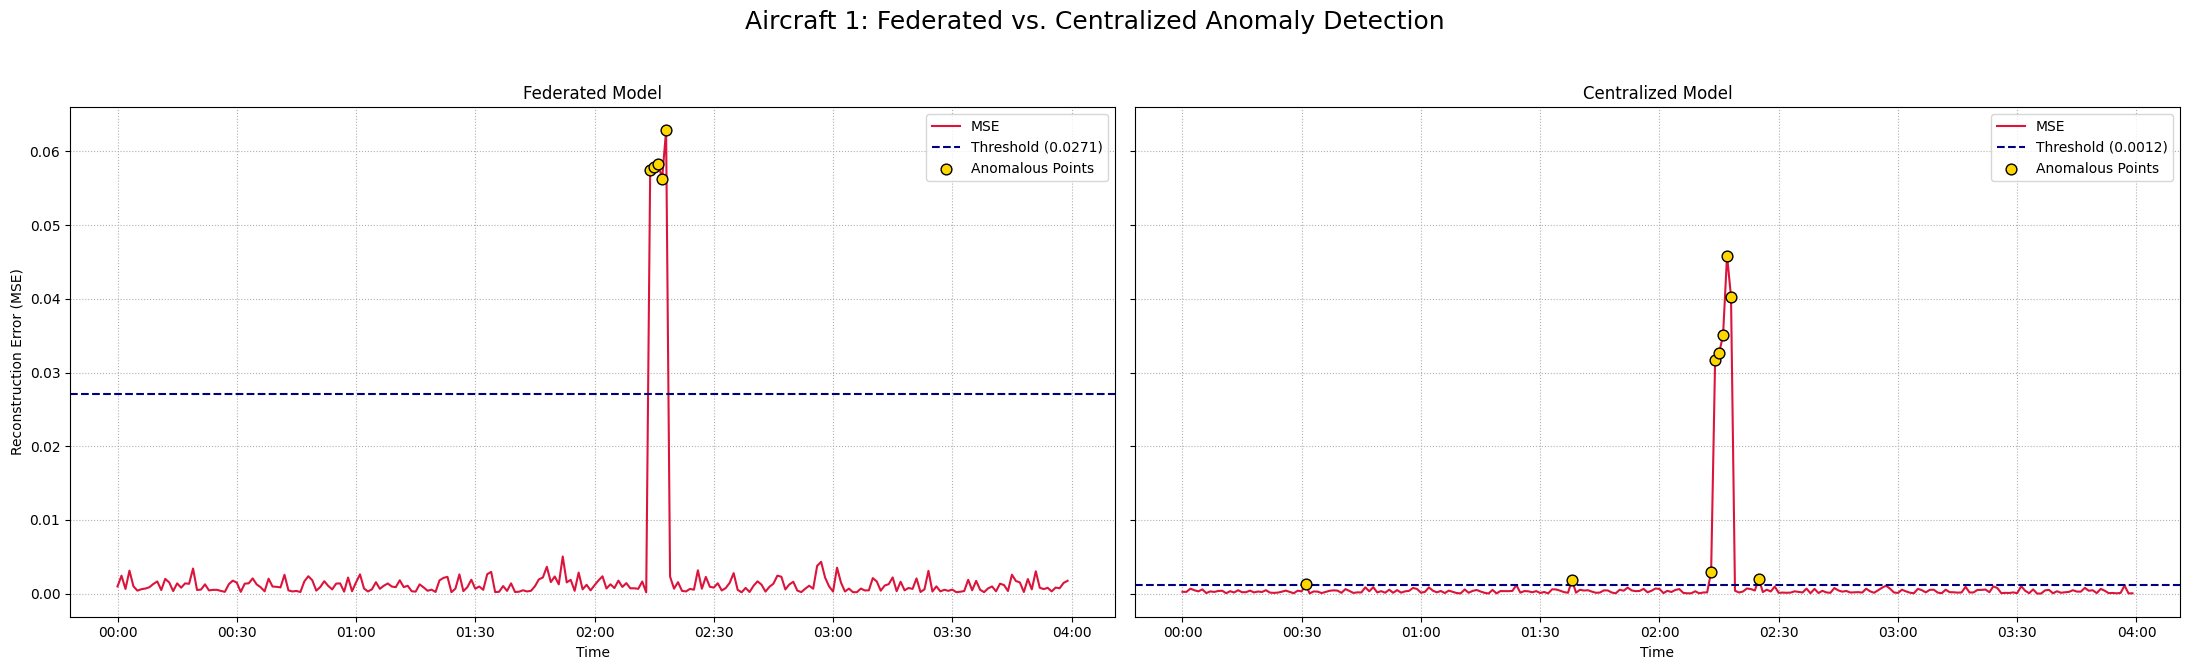

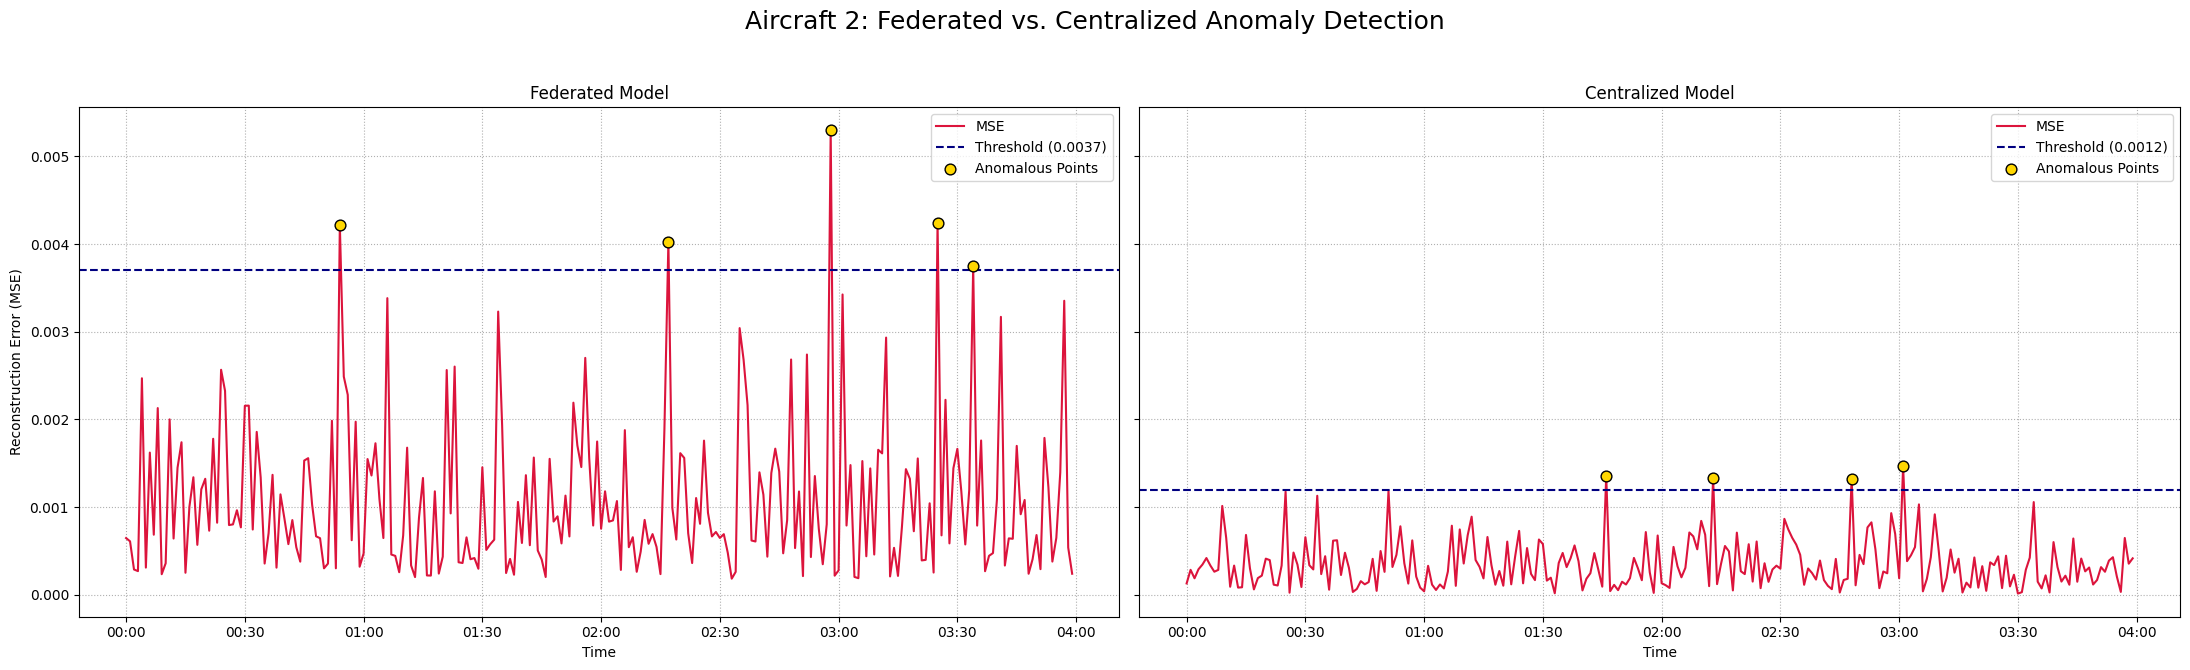

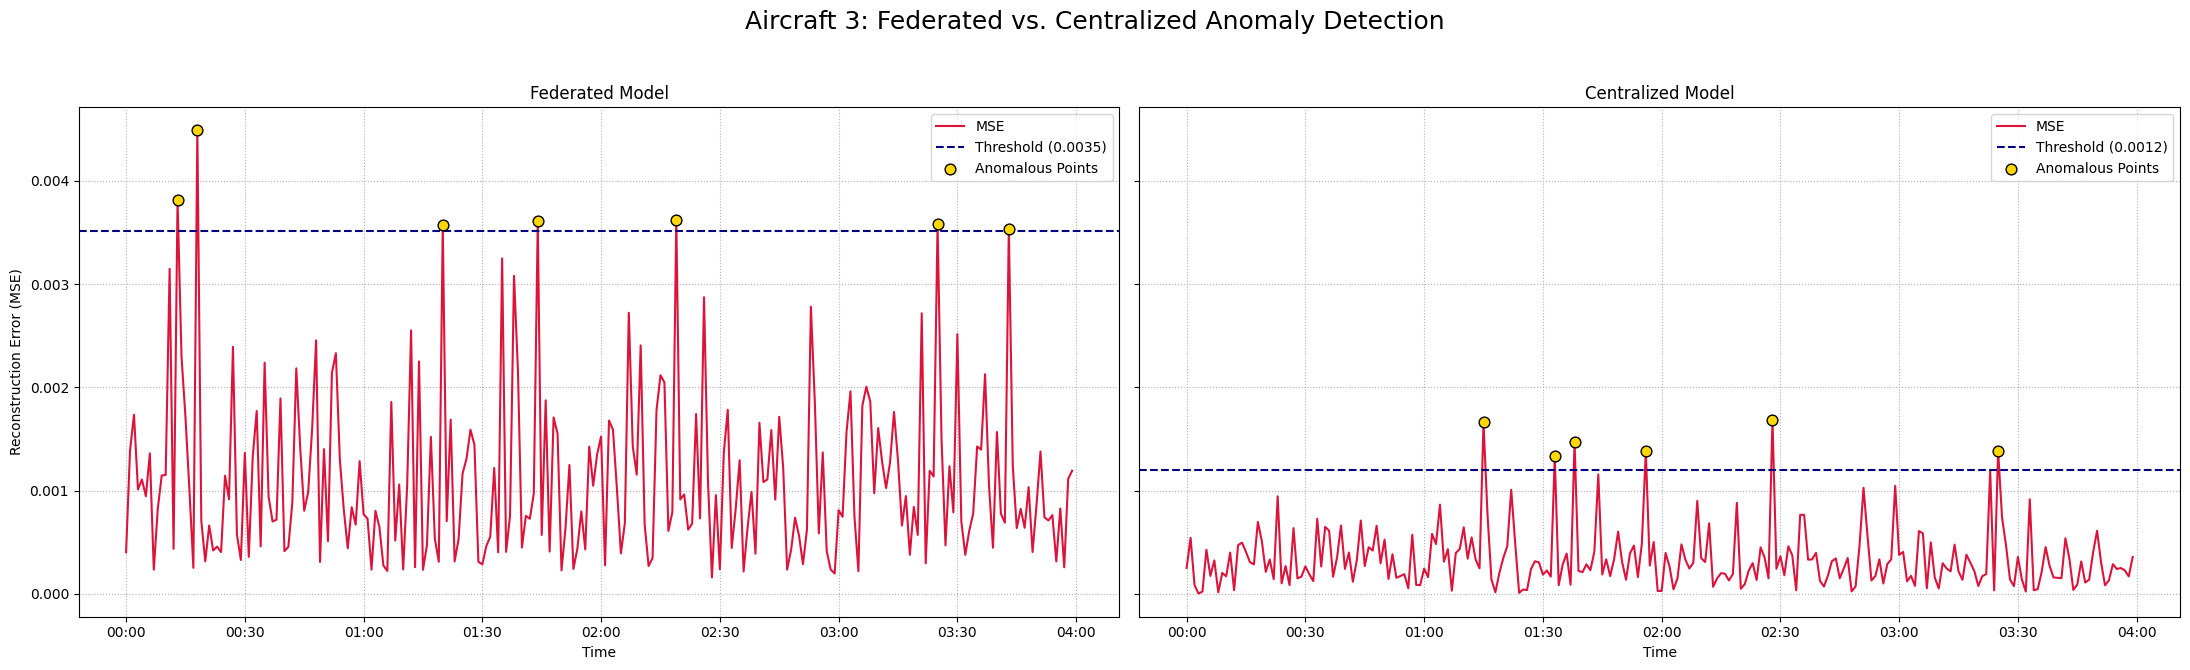

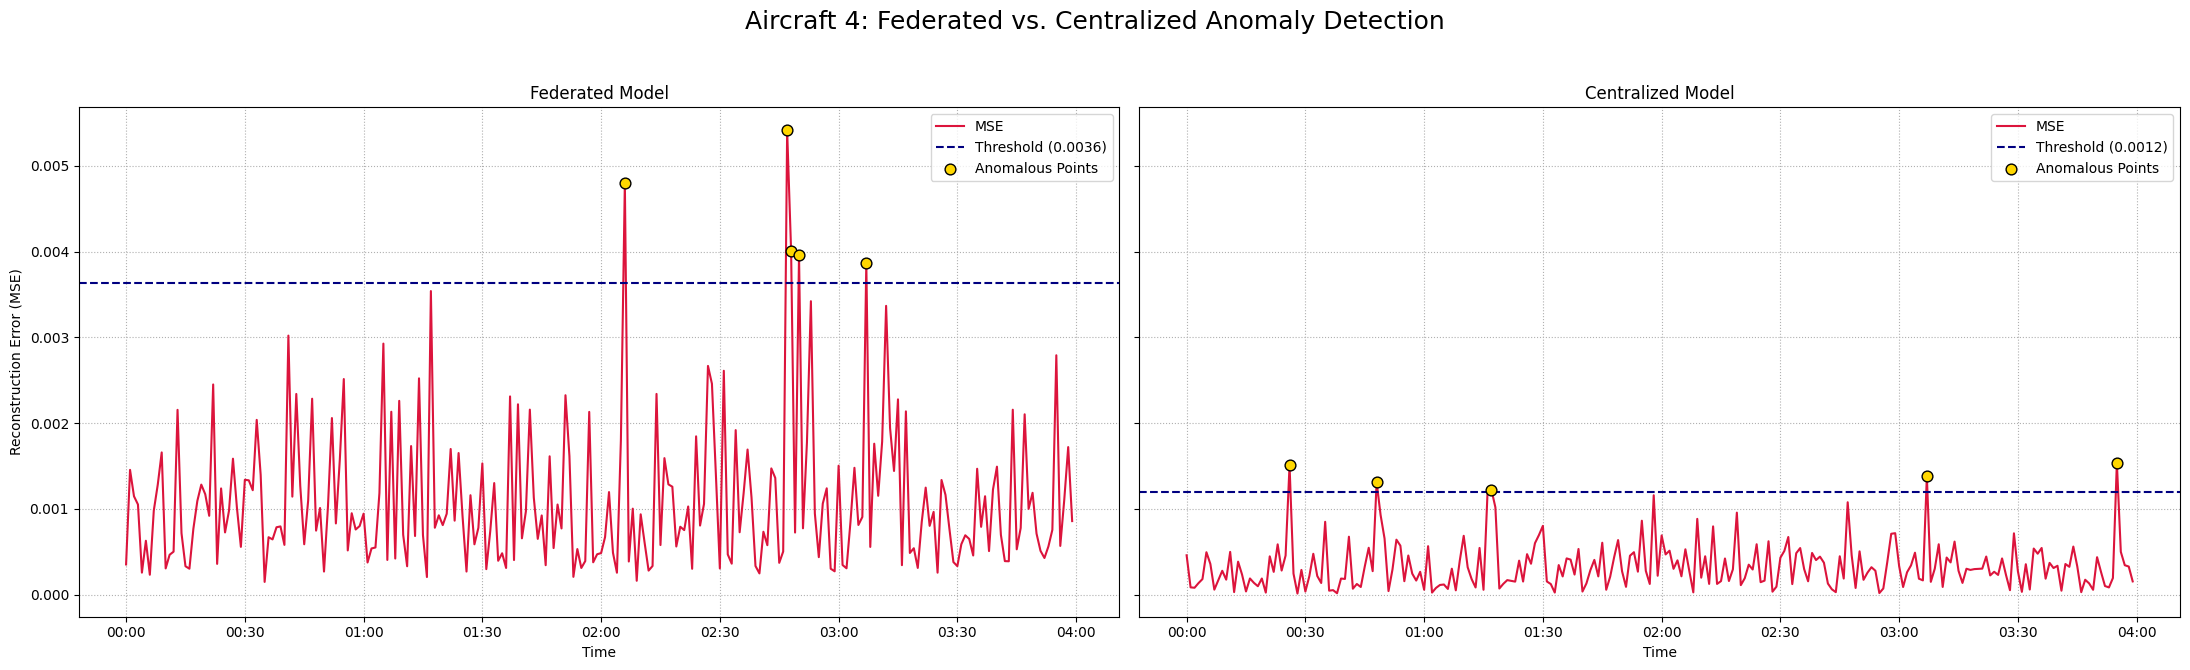

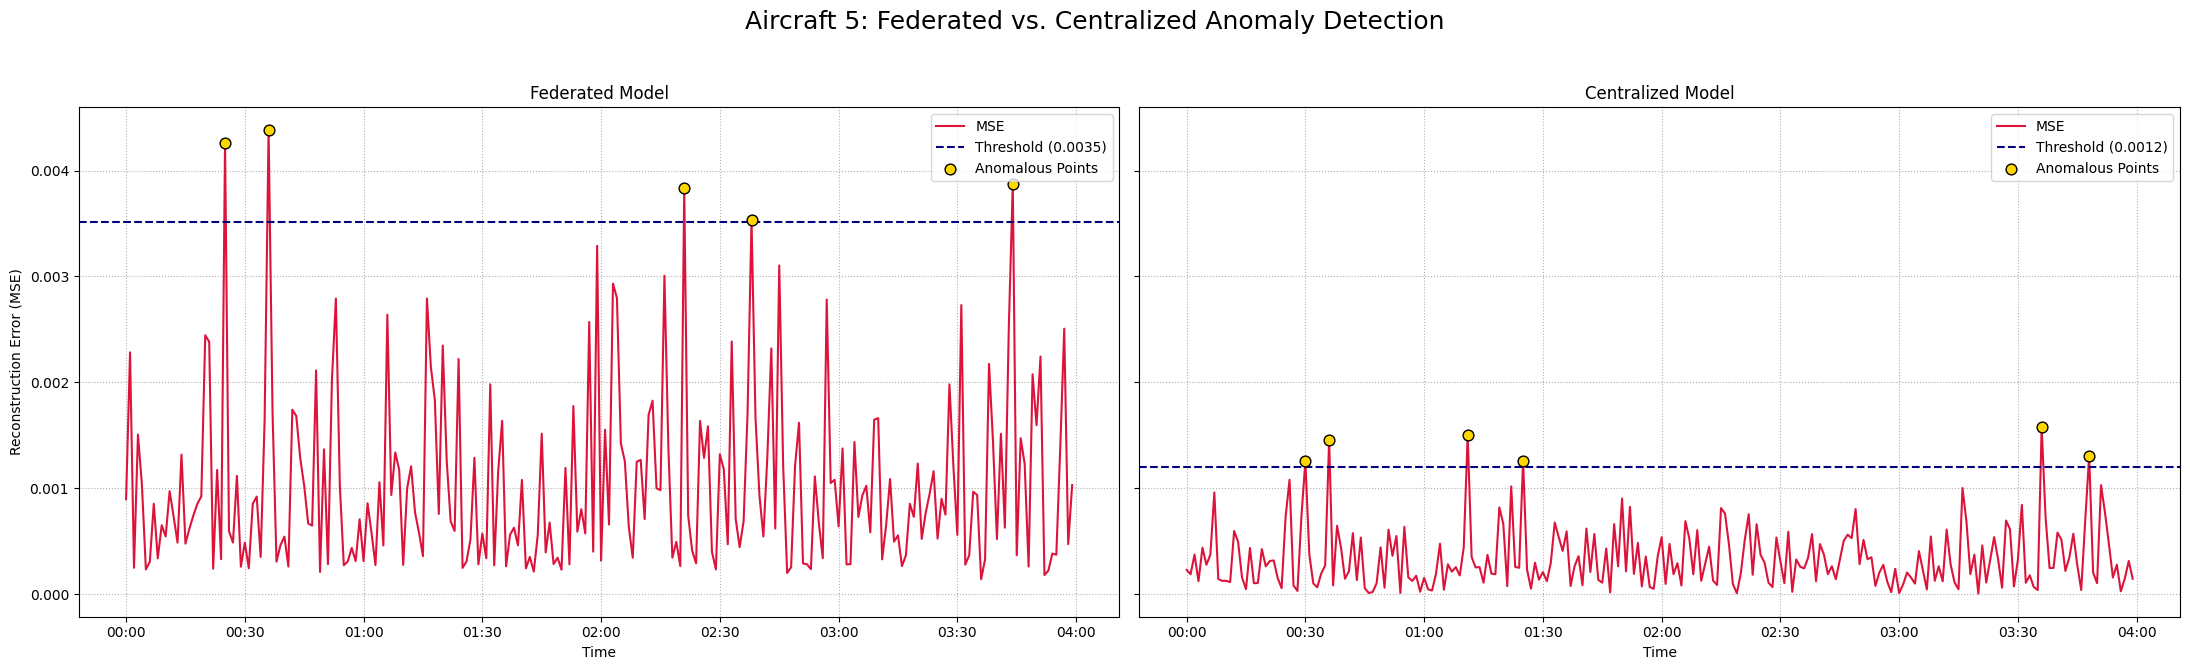

In [33]:
print("\n--- Generating Comparison Plots ---")

# Helper function to get reconstruction errors
def get_errors(model, data_tensor):
    with torch.no_grad():
        model.eval()
        reconstructed = model(data_tensor)
        return torch.mean((data_tensor - reconstructed)**2, dim=1).numpy()

# Generate a plot for each aircraft
for i, file_path in enumerate(file_paths):
    client_id = i + 1
    
    # Load the aircraft's full dataset
    client_df = pd.read_csv(file_path)
    timestamps = pd.to_datetime(client_df['timestamp'])
    
    # Scale data using the GLOBAL scaler
    # Scale data using fixed ranges (same as training)
    scaler = get_aircraft_scaler(include_anomalies=False)
    client_tensor = torch.tensor(scaler.transform(client_df[DATA_CONFIG['sensor_names']]), dtype=torch.float32)

    # Get errors and threshold for Federated Model
    fed_errors = get_errors(federated_model, client_tensor)
    fed_threshold = np.mean(fed_errors) + 3 * np.std(fed_errors)
    fed_anomalies = fed_errors > fed_threshold

    # Get errors and threshold for Centralized Model
    cen_errors = get_errors(centralized_model, client_tensor)
    normal_data_errors = get_errors(centralized_model, train_tensor)
    cen_threshold = np.mean(normal_data_errors) + 3 * np.std(normal_data_errors)
    cen_anomalies = cen_errors > cen_threshold

    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
    fig.suptitle(f'Aircraft {client_id}: Federated vs. Centralized Anomaly Detection', fontsize=18)

    # Federated Plot
    ax1.plot(timestamps, fed_errors, label='MSE', color='crimson')
    ax1.axhline(fed_threshold, color='navy', linestyle='--', label=f'Threshold ({fed_threshold:.4f})')
    ax1.scatter(timestamps[fed_anomalies], fed_errors[fed_anomalies], s=60, color='gold', edgecolor='black', label='Anomalous Points', zorder=5)
    ax1.set_title('Federated Model')
    ax1.set_ylabel("Reconstruction Error (MSE)"); ax1.set_xlabel("Time")
    ax1.grid(True, which='both', linestyle=':'); ax1.legend()
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    # Centralized Plot
    ax2.plot(timestamps, cen_errors, label='MSE', color='crimson')
    ax2.axhline(cen_threshold, color='navy', linestyle='--', label=f'Threshold ({cen_threshold:.4f})')
    ax2.scatter(timestamps[cen_anomalies], cen_errors[cen_anomalies], s=60, color='gold', edgecolor='black', label='Anomalous Points', zorder=5)
    ax2.set_title('Centralized Model')
    ax2.set_xlabel("Time")
    ax2.grid(True, which='both', linestyle=':'); ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

In [34]:
print("\n--- Model Performance Statistics ---")

centralized_stats = []
federated_stats = []

# Ensure models are in evaluation mode
centralized_model.eval()
federated_model.eval()

# Use the same globally-fitted scaler for a fair comparison
# This 'scaler' object was fitted on the combined normal data during centralized training
global_scaler = scaler

with torch.no_grad():
    for i, file_path in enumerate(file_paths):
        client_id = i + 1
        df = pd.read_csv(file_path)
        sensor_data = df[DATA_CONFIG['sensor_names']]
        n_points = len(sensor_data)
        
        # Scale data using the single global scaler
        # Scale data using fixed ranges
        scaler = get_aircraft_scaler(include_anomalies=False)
        scaled_data = scaler.transform(sensor_data)
        data_tensor = torch.tensor(scaled_data, dtype=torch.float32)
        
        # --- Centralized Model Evaluation ---
        reconstructed_centralized = centralized_model(data_tensor)
        # Calculate per-point MSE loss
        mse_centralized = torch.mean((data_tensor - reconstructed_centralized)**2, dim=1)
        centralized_stats.append({
            'client_id': client_id,
            'status': 'Anomalous' if "anomalous" in file_path else 'Normal',
            'mean_mse': mse_centralized.mean().item(),
            'max_mse': mse_centralized.max().item(),
            'std_mse': mse_centralized.std().item(),
            'n_points': n_points
        })
        
        # --- Federated Model Evaluation ---
        reconstructed_federated = federated_model(data_tensor)
        # Calculate per-point MSE loss
        mse_federated = torch.mean((data_tensor - reconstructed_federated)**2, dim=1)
        federated_stats.append({
            'client_id': client_id,
            'status': 'Anomalous' if "anomalous" in file_path else 'Normal',
            'mean_mse': mse_federated.mean().item(),
            'max_mse': mse_federated.max().item(),
            'std_mse': mse_federated.std().item(),
            'n_points': n_points
        })

# Create DataFrames for a clean display
centralized_df = pd.DataFrame(centralized_stats).set_index('client_id')
federated_df = pd.DataFrame(federated_stats).set_index('client_id')

# Set pandas display options for better readability
pd.set_option('display.float_format', '{:.6f}'.format)

print("\n--- Centralized Model Performance ---")
display(centralized_df[['status', 'mean_mse', 'max_mse', 'std_mse', 'n_points']])

print("\n--- Federated Model Performance ---")
display(federated_df[['status', 'mean_mse', 'max_mse', 'std_mse', 'n_points']])


--- Model Performance Statistics ---

--- Centralized Model Performance ---


,status,mean_mse,max_mse,std_mse,n_points
client_id,,,,,
1,Anomalous,0.001118,0.045822,0.005323,240
2,Normal,0.000354,0.001467,0.000281,240
3,Normal,0.000340,0.001687,0.000293,240
4,Normal,0.000336,0.001538,0.000277,240
5,Normal,0.000341,0.001577,0.000291,240



--- Federated Model Performance ---


,status,mean_mse,max_mse,std_mse,n_points
client_id,,,,,
1,Anomalous,0.002332,0.062837,0.008273,240
2,Normal,0.001095,0.005294,0.000872,240
3,Normal,0.001116,0.004489,0.000802,240
4,Normal,0.001105,0.005411,0.000845,240
5,Normal,0.001040,0.004378,0.000828,240



--- Visualizing Performance Statistics ---


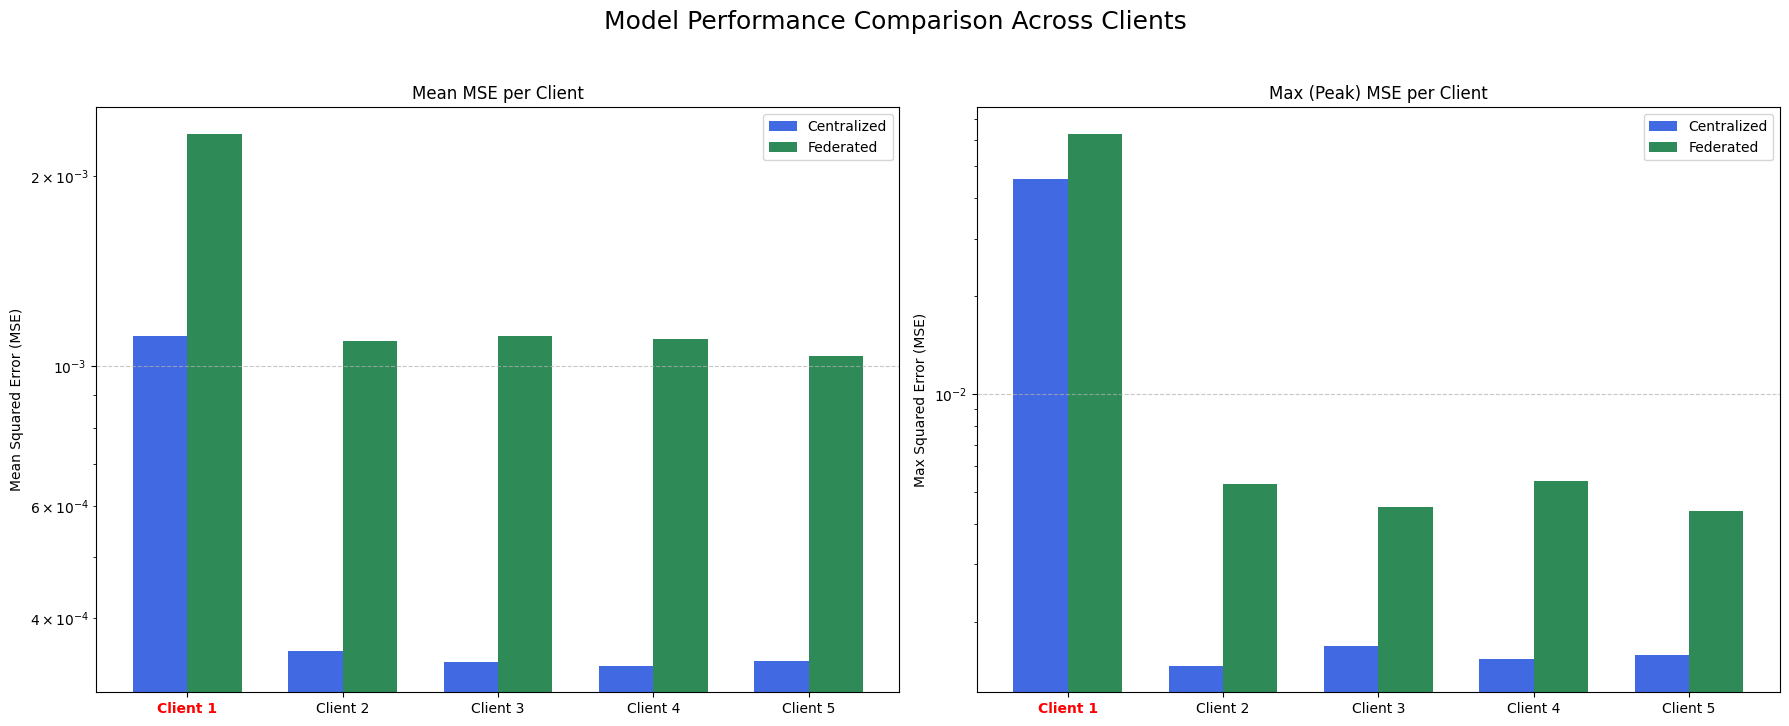

In [35]:
print("\n--- Visualizing Performance Statistics ---")

# Create a figure for the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Performance Comparison Across Clients', fontsize=18, y=1.03)

# --- Bar Chart for Mean MSE ---
bar_width = 0.35
client_ids = centralized_df.index
x = np.arange(len(client_ids))

rects1 = ax1.bar(x - bar_width/2, centralized_df['mean_mse'], bar_width, label='Centralized', color='royalblue')
rects2 = ax1.bar(x + bar_width/2, federated_df['mean_mse'], bar_width, label='Federated', color='seagreen')

ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.set_title('Mean MSE per Client')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Client {id}' for id in client_ids])
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_yscale('log') # Use log scale for better visibility

# --- Bar Chart for Max MSE ---
rects3 = ax2.bar(x - bar_width/2, centralized_df['max_mse'], bar_width, label='Centralized', color='royalblue')
rects4 = ax2.bar(x + bar_width/2, federated_df['max_mse'], bar_width, label='Federated', color='seagreen')

ax2.set_ylabel('Max Squared Error (MSE)')
ax2.set_title('Max (Peak) MSE per Client')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Client {id}' for id in client_ids])
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log') # Log scale is useful for comparing large spikes

# Add a visual indicator for the anomalous client
for ax in [ax1, ax2]:
    for i, client_id in enumerate(client_ids):
        # Find which client is anomalous from the dataframe status
        if centralized_df.loc[client_id, 'status'] == 'Anomalous':
            ax.get_xticklabels()[i].set_color('red')
            ax.get_xticklabels()[i].set_weight('bold')

fig.tight_layout()
plt.show()

In [36]:
print("\n--- Simple Epoch Comparison: Federated vs Centralized ---")

# Test different epoch configurations
epochs_to_test = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100,110,120,130,140,150,160,170,180,190,200]

# Store results
results = []

print("Testing different epoch configurations...")


--- Simple Epoch Comparison: Federated vs Centralized ---
Testing different epoch configurations...


In [37]:
for epochs in epochs_to_test:
    print(f"\n--- Testing {epochs} epochs ---")
    
    # Train centralized model
    centralized_test = Autoencoder(
        input_dim=MODEL_CONFIG['input_dim'],
        hidden_dim=MODEL_CONFIG['hidden_dim'],
        latent_dim=MODEL_CONFIG['latent_dim']
    )
    centralized_test.train_on_tensor(train_tensor, num_epochs=epochs, lr=TRAINING_CONFIG['learning_rate'])
    
    # Train federated model
    test_clients = [
        FederatedClient(client_id=i + 1, file_path=file_paths[i])
        for i in range(DATA_CONFIG['num_aircraft'])
    ]
    test_base_model = Autoencoder(
        input_dim=MODEL_CONFIG['input_dim'],
        hidden_dim=MODEL_CONFIG['hidden_dim'],
        latent_dim=MODEL_CONFIG['latent_dim']
    )
    test_server = CentralizedServer(clients=test_clients, model=test_base_model)
    test_server.train(rounds=10, local_epochs=epochs//10, lr=TRAINING_CONFIG['learning_rate'])
    
    # Calculate MSE for both models
    centralized_test.eval()
    test_server.global_model.eval()
    
    with torch.no_grad():
        # Centralized MSE
        cen_reconstructed = centralized_test(train_tensor)
        cen_mse = nn.MSELoss()(cen_reconstructed, train_tensor).item()
        
        # Federated MSE
        fed_reconstructed = test_server.global_model(train_tensor)
        fed_mse = nn.MSELoss()(fed_reconstructed, train_tensor).item()
    
    results.append({
        'epochs': epochs,
        'centralized_mse': cen_mse,
        'federated_mse': fed_mse,
        'federated_better': fed_mse < cen_mse
    })
    
    print(f"   Centralized MSE: {cen_mse:.6f}")
    print(f"   Federated MSE: {fed_mse:.6f}")
    print(f"   Federated better: {fed_mse < cen_mse}")


--- Testing 10 epochs ---
Starting training...
  Epoch [10/10], Loss: 0.001255

ROUND 1/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 2/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 3/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 4/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 5/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 6/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 7/10
  -> Training Client 1...
  -> Training Client 2...
  ->

In [38]:
# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n--- Results Summary ---")
display(results_df)

# Find crossover point
crossover_found = False
for i, row in results_df.iterrows():
    if row['federated_better']:
        print(f"\n🎯 CROSSOVER POINT FOUND!")
        print(f"   Federated Learning becomes better at {row['epochs']} epochs")
        print(f"   Centralized MSE: {row['centralized_mse']:.6f}")
        print(f"   Federated MSE: {row['federated_mse']:.6f}")
        crossover_found = True
        break

if not crossover_found:
    print("\n❌ No crossover point found in tested range")


--- Results Summary ---


,epochs,centralized_mse,federated_mse,federated_better
0,10,0.001096,0.015339,False
1,20,0.000572,0.005245,False
2,30,0.000461,0.007505,False
3,40,0.000557,0.009359,False
4,50,0.000470,0.000449,True
5,60,0.000127,0.000748,False
6,70,0.000374,0.000134,True
7,80,0.000084,0.000376,False
8,90,0.000057,0.000091,False
9,100,0.000272,0.000076,True



🎯 CROSSOVER POINT FOUND!
   Federated Learning becomes better at 50 epochs
   Centralized MSE: 0.000470
   Federated MSE: 0.000449


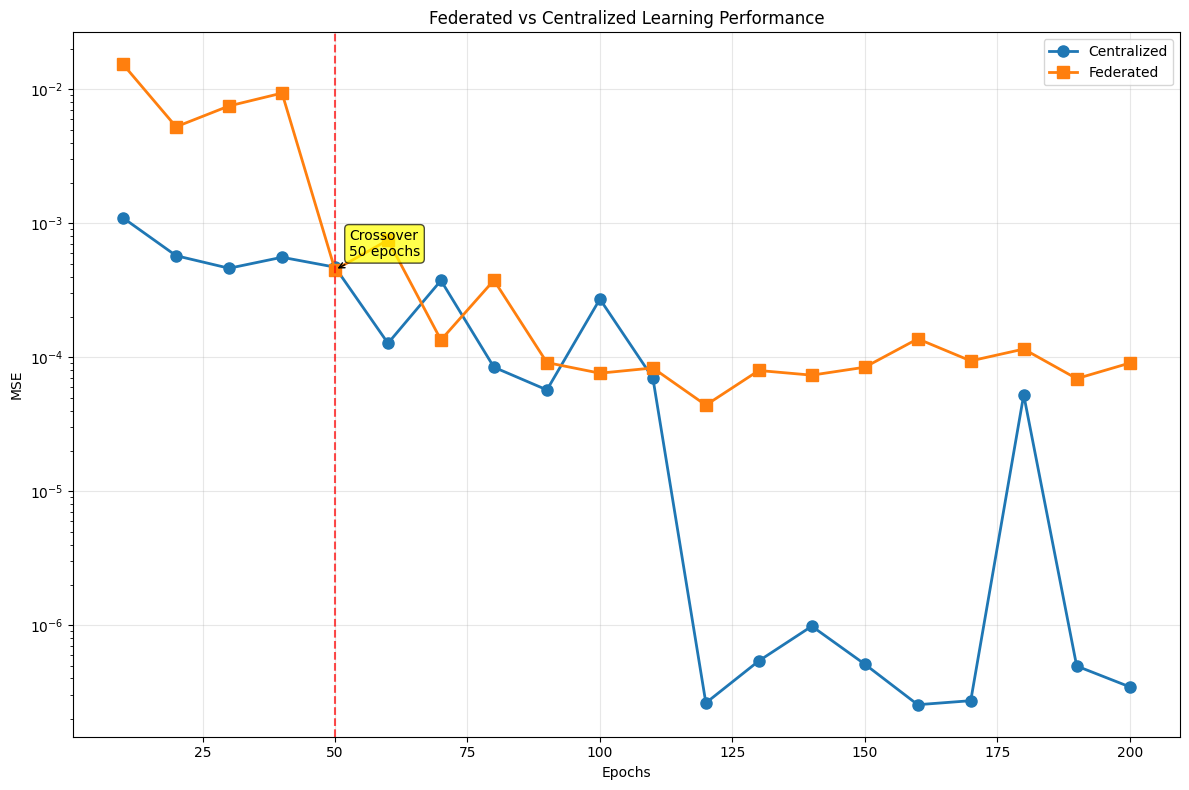

In [39]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(results_df['epochs'], results_df['centralized_mse'], 
         marker='o', label='Centralized', linewidth=2, markersize=8)
plt.plot(results_df['epochs'], results_df['federated_mse'], 
         marker='s', label='Federated', linewidth=2, markersize=8)

plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Federated vs Centralized Learning Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Highlight crossover point
if crossover_found:
    for i, row in results_df.iterrows():
        if row['federated_better']:
            plt.axvline(x=row['epochs'], color='red', linestyle='--', alpha=0.7, 
                       label=f'Crossover at {row["epochs"]} epochs')
            plt.annotate(f'Crossover\n{row["epochs"]} epochs', 
                        xy=(row['epochs'], row['federated_mse']),
                        xytext=(10, 10), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                        arrowprops=dict(arrowstyle='->'))
            break

plt.tight_layout()
plt.show()